# Outbreak regression baseline on `feature_county_day`

Fits a **logistic regression** predicting `target_outbreak_next_7d` — will this county have a
USDA-confirmed HPAI poultry detection in the next 7 days? — from the environmental, spatial and
exposure variables in the modeling surface. This is the **in-house baseline** that sentiment will
later be tested against for incremental lift; it is not an attempt to reproduce Zou et al.

## What this notebook is careful about

Four things will silently produce a wrong-but-plausible answer on this dataset. Each is handled
explicitly below, and each is worth understanding before changing anything.

1. **The split is temporal, never random.** County-days are massively autocorrelated in both space
   and time. A random train/test split lets the model see the same outbreak cluster on both sides
   and reports a fantasy score.
2. **The positive class is ~0.3%.** ROC-AUC looks impressive at that base rate almost regardless of
   the model. **Average precision (PR-AUC) against the base rate is the honest headline**, so both
   are reported.
3. **Negatives are subsampled in TRAINING ONLY; the test set stays complete.** Under case-control
   sampling the logistic slopes are unbiased and only the intercept shifts, so it is corrected
   analytically before any probability is evaluated. Had the test set also been sampled, every
   precision-based metric would be inflated.
4. **NULL is not zero.** Suppressed NASS inventory and "no outbreak in the past 365 days" are
   missing/censored, not zero, and are given explicit indicator columns rather than being filled.

Requires the modeling extra and a running Cloud SQL proxy:

```bash
uv sync --extra modeling --extra dev
.\cloud-sql-proxy.exe harvard-capstone-499102:us-central1:h5n1-pg --port 5433
uv run --extra modeling --extra dev jupyter lab
```

In [1]:
# --- configuration -------------------------------------------------------------
# Every analysis choice worth arguing about is a constant here.

STUDY_START = "2022-02-08"   # first US poultry detection; earlier days are all-zero DV
SPLIT_DATE  = "2025-01-01"   # train < SPLIT_DATE <= test. TEMPORAL, never random.

# Keep every training positive, sample training negatives. Test is untouched.
NEG_SAMPLE_RATE = 0.05
RANDOM_STATE    = 20260728

# fact_bird_density stops 2025-07-10 (the NABBP source's own extent, not a load bug:
# releases are annual and the current one is "1960-2025 retrieved 2025-07-11"). That is
# inside the test window, so banding features would be structurally zero for most of the
# test period while being live in training -- a train/test distribution shift that has
# nothing to do with epidemiology. Excluded by default.
INCLUDE_BANDING = False

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (average_precision_score, brier_score_loss,
                             precision_recall_curve, roc_auc_score, roc_curve)
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from h5n1.db import get_engine

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 60)

# --- plot style: recessive grid, thin marks, text in ink rather than series color ---
INK, INK_2, SURFACE = "#0b0b0b", "#52514e", "#fcfcfb"
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#d8d7d2", "axes.linewidth": 0.8, "axes.labelcolor": INK_2,
    "axes.titlesize": 11, "axes.titleweight": "600", "axes.titlecolor": INK,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_2, "ytick.color": INK_2, "font.size": 9.5,
    "lines.linewidth": 2.0, "legend.frameon": False,
})

## 1. Load

Filtering happens server-side. Three predicates matter:

- `is_conus` — Alaska and Hawaii have no weather, no migration axis and no proximity rows, so they
  would enter as ~300k rows of structural NULLs.
- `target_complete_7d` — near the data horizon the forward window is truncated, so its zeros are
  partly fictional. Dropping these is what stops the model being rewarded for a quiet tail.
- The negative subsample applies **only before `SPLIT_DATE`**.

In [3]:
QUERY = f"""
SELECT fips, day, state,
       target_outbreak_next_7d,
       outbreak, own_outbreaks_7d, own_outbreaks_21d, own_outbreaks_60d,
       nbr_infected_counties_7d, nbr_infected_counties_21d, nbr_infected_counties_60d,
       nbr_infections_7d, nbr_infections_21d, nbr_infections_60d,
       nbr_wild_detections_7d, nbr_wild_detections_21d, nbr_wild_detections_60d,
       wild_detections_7d, wild_detections_21d, wild_detections_60d,
       band_count_21d, nbr_band_count_21d, has_band_coverage,
       days_since_outbreak_county, days_since_outbreak_neighbor,
       breeding_side_pressure, wintering_side_pressure,
       temp_min_7d_c, temp_max_7d_c, precip_7d_mm, precip_days_7d,
       poultry_operations, layer_operations, broiler_operations,
       turkey_operations, duck_operations, layer_inventory,
       population, pop_density_sqmi, n_neighbors, doy_sin, doy_cos
FROM feature_county_day
WHERE is_conus
  AND target_complete_7d
  AND day >= '{STUDY_START}'
  AND (
        day >= '{SPLIT_DATE}'          -- test period: complete, never sampled
     OR target_outbreak_next_7d        -- training positives: keep all
     OR random() < {NEG_SAMPLE_RATE}   -- training negatives: sample
      )
"""

df = pd.read_sql(QUERY, get_engine())
df["day"] = pd.to_datetime(df["day"])
print(f"{len(df):,} rows x {df.shape[1]} columns")
print(f"date range {df.day.min().date()} .. {df.day.max().date()}")

1,912,687 rows x 42 columns
date range 2022-02-08 .. 2026-07-14


In [4]:
# --- audit: confirm the sampling did what we think, and see the real base rate ----
is_train = df.day < SPLIT_DATE
audit = pd.DataFrame({
    "rows":      [is_train.sum(), (~is_train).sum()],
    "positives": [df.loc[is_train, "target_outbreak_next_7d"].sum(),
                  df.loc[~is_train, "target_outbreak_next_7d"].sum()],
}, index=["train (negatives sampled)", "test (complete)"])
audit["positive_rate"] = (audit.positives / audit.rows).map("{:.4%}".format)
display(audit)

print("\nTest-set positive rate is the POPULATION base rate -- the number every")
print("precision metric below has to be judged against.")
print(f"\nMissingness (NULL != 0 -- these get indicators, not fillna(0)):")
print(df[["days_since_outbreak_county", "days_since_outbreak_neighbor",
          "layer_inventory", "temp_max_7d_c"]].isna().mean().map("{:.2%}".format).to_string())

,rows,positives,positive_rate
train (negatives sampled),172207,8136,4.7245%
test (complete),1740480,4366,0.2509%



Test-set positive rate is the POPULATION base rate -- the number every
precision metric below has to be judged against.

Missingness (NULL != 0 -- these get indicators, not fillna(0)):
days_since_outbreak_county      91.35%
days_since_outbreak_neighbor    65.58%
layer_inventory                 11.21%
temp_max_7d_c                    0.16%


## 2. Feature preparation

Three transformations, each for a stated reason:

- **`log1p` on every count/exposure column.** Layer inventory spans 0 to 13.7M and poultry
  operations 0 to ~2,000; untransformed, a handful of egg-belt counties dominate the fit.
- **Censored recency → capped value + indicator.** `days_since_outbreak_*` is NULL when nothing
  happened in the trailing 365 days. That is *right-censoring*, not missingness: filling it with 0
  would say "an outbreak just happened here."
- **Suppressed inventory → median + indicator.** NASS withholds layer inventory for 348 counties
  that demonstrably behave like mid-to-large layer operations. The indicator lets the model price
  the withholding itself, which carries information.

In [5]:
COUNT_COLS = [
    "own_outbreaks_7d", "own_outbreaks_21d", "own_outbreaks_60d",
    "nbr_infected_counties_7d", "nbr_infected_counties_21d", "nbr_infected_counties_60d",
    "nbr_infections_7d", "nbr_infections_21d", "nbr_infections_60d",
    "nbr_wild_detections_7d", "nbr_wild_detections_21d", "nbr_wild_detections_60d",
    "wild_detections_7d", "wild_detections_21d", "wild_detections_60d",
    "breeding_side_pressure", "wintering_side_pressure",
    "poultry_operations", "layer_operations", "broiler_operations",
    "turkey_operations", "duck_operations", "population",
]
PASSTHROUGH = ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm",
               "doy_sin", "doy_cos", "n_neighbors"]

X = pd.DataFrame(index=df.index)

for c in COUNT_COLS:
    X[f"log_{c}"] = np.log1p(df[c].clip(lower=0))

# Censored recency: cap beyond the 365-day lookback, and flag that it was censored.
for c in ["days_since_outbreak_county", "days_since_outbreak_neighbor"]:
    X[f"{c}_censored"] = df[c].isna().astype(int)
    X[c] = df[c].fillna(400) / 100.0     # /100 keeps it on a comparable scale

# Suppressed NASS inventory: indicator + median fill. Never a plain 0.
X["layer_inventory_suppressed"] = (df.layer_inventory.isna() & (df.layer_operations > 0)).astype(int)
X["log_layer_inventory"] = np.log1p(df.layer_inventory.fillna(df.layer_inventory.median()))

if INCLUDE_BANDING:
    X["log_band_count_21d"] = np.log1p(df.band_count_21d.clip(lower=0))
    X["log_nbr_band_count_21d"] = np.log1p(df.nbr_band_count_21d.clip(lower=0))

for c in PASSTHROUGH:
    X[c] = df[c]

# Weather is a MEASUREMENT: a NULL means the station did not report, not 0 degrees.
# Median-fill with an indicator so the model can separate "cold" from "unobserved".
X["weather_missing"] = df.temp_max_7d_c.isna().astype(int)
for c in ["temp_min_7d_c", "temp_max_7d_c", "precip_7d_mm"]:
    X[c] = X[c].fillna(X.loc[df.day < SPLIT_DATE, c].median())

y = df.target_outbreak_next_7d.astype(int)
print(f"design matrix: {X.shape[0]:,} x {X.shape[1]}   NaNs remaining: {int(X.isna().sum().sum())}")

design matrix: 1,912,687 x 36   NaNs remaining: 0


In [6]:
# --- leakage assertion: no target_* or same-day outbreak column may reach the model ---
banned = [c for c in X.columns if c.startswith("target_") or c == "outbreak"]
assert not banned, f"LEAKAGE: {banned}"
assert X.isna().sum().sum() == 0, "NaNs in design matrix"
print("leakage check passed -- no forward-looking or same-day columns in X")
print("\nNOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]")
print("and legitimately knowable, but they are also the strongest single predictor.")
print("Set them aside if you want to see what the environmental signal does alone.")

leakage check passed -- no forward-looking or same-day columns in X

NOTE: own_outbreaks_7d/21d/60d ARE included. They are past-only [day-w, day-1]
and legitimately knowable, but they are also the strongest single predictor.
Set them aside if you want to see what the environmental signal does alone.


## 3. Temporal split and fit

`class_weight="balanced"` is deliberately **not** used. Negatives are already subsampled, and
stacking class weights on top would distort the intercept a second time in a way the analytic
correction below does not account for.

In [7]:
train, test = df.day < SPLIT_DATE, df.day >= SPLIT_DATE
X_tr, X_te, y_tr, y_te = X[train], X[test], y[train], y[test]

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=2000, C=1.0, random_state=RANDOM_STATE),
)
model.fit(X_tr, y_tr)

# --- prior correction for case-control sampling -------------------------------
# Positives kept with probability 1, negatives with probability NEG_SAMPLE_RATE.
# The slopes are unbiased; only the intercept is offset, by log(tau_1 / tau_0).
lr = model.named_steps["logisticregression"]
print(f"fitted intercept   {lr.intercept_[0]:+.4f}")
lr.intercept_ += np.log(NEG_SAMPLE_RATE)
print(f"corrected intercept {lr.intercept_[0]:+.4f}   (shift {np.log(NEG_SAMPLE_RATE):+.4f})")

p_te = model.predict_proba(X_te)[:, 1]

fitted intercept   -3.8398
corrected intercept -6.8355   (shift -2.9957)


In [8]:
base_rate = y_te.mean()
scores = pd.Series({
    "test rows":            f"{len(y_te):,}",
    "test positives":       f"{int(y_te.sum()):,}",
    "base rate":            f"{base_rate:.4%}",
    "ROC-AUC":              f"{roc_auc_score(y_te, p_te):.4f}",
    "PR-AUC (avg prec.)":   f"{average_precision_score(y_te, p_te):.4f}",
    "PR-AUC lift vs base":  f"{average_precision_score(y_te, p_te) / base_rate:.1f}x",
    "Brier score":          f"{brier_score_loss(y_te, p_te):.6f}",
    "mean predicted prob":  f"{p_te.mean():.4%}",
})
print(scores.to_string())
print("\nRead PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at")
print("this prevalence -- a model can score well on it while being useless in practice.")

test rows              1,740,480
test positives             4,366
base rate                0.2509%
ROC-AUC                   0.8763
PR-AUC (avg prec.)        0.1183
PR-AUC lift vs base        47.2x
Brier score             0.002527
mean predicted prob      0.3720%

Read PR-AUC against the base rate, not against 1.0. ROC-AUC is flattering at
this prevalence -- a model can score well on it while being useless in practice.


## 4. Diagnostics

Precision-recall against the base rate is the operational question: *if we flag the top N
county-days, what fraction are real?* The calibration curve then asks whether the predicted
probabilities can be believed as probabilities — which matters if these ever feed a decision rule.

findfont: Failed to find font weight 600, now using 700.


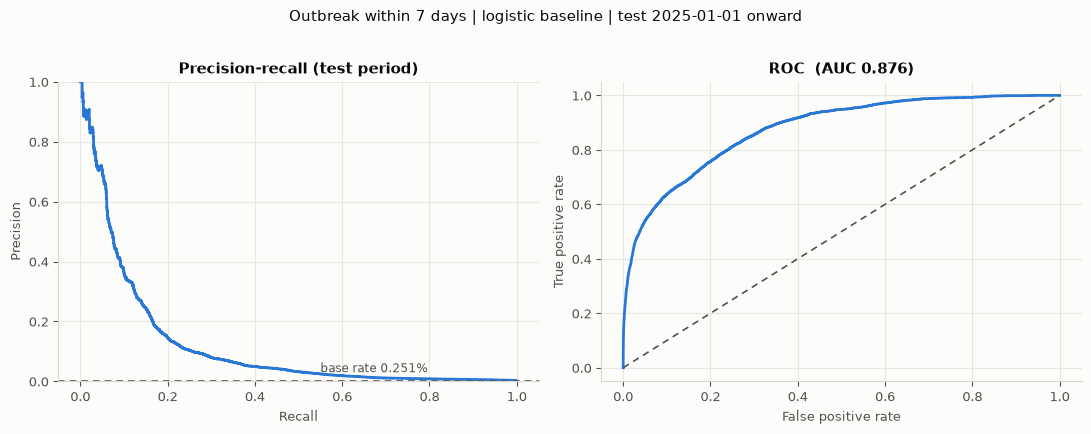

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[0].plot(rec, prec, color=BLUE)
axes[0].axhline(base_rate, color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[0].annotate(f"base rate {base_rate:.3%}", (0.55, base_rate), textcoords="offset points",
                 xytext=(0, 6), color=INK_2, fontsize=8.5)
axes[0].set(xlabel="Recall", ylabel="Precision", ylim=(0, 1),
            title="Precision-recall (test period)")

fpr, tpr, _ = roc_curve(y_te, p_te)
axes[1].plot(fpr, tpr, color=BLUE)
axes[1].plot([0, 1], [0, 1], color=INK_2, lw=1.2, ls=(0, (4, 3)))
axes[1].set(xlabel="False positive rate", ylabel="True positive rate",
            title=f"ROC  (AUC {roc_auc_score(y_te, p_te):.3f})")

fig.suptitle(f"Outbreak within 7 days | logistic baseline | test {SPLIT_DATE} onward",
             fontsize=10.5, color=INK, y=1.02)
fig.tight_layout()
plt.show()

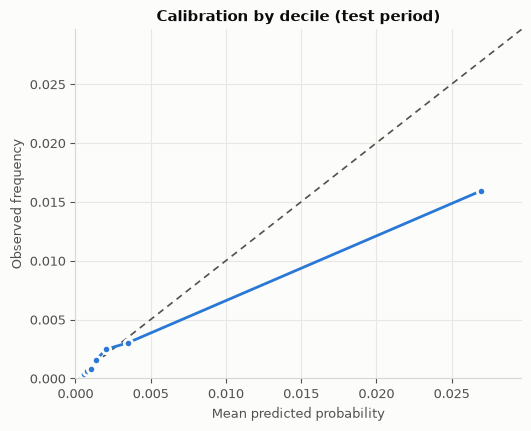

,pred,obs,n
bin,,,
0,0.0194%,0.0023%,174048
1,0.0325%,0.0161%,174048
2,0.0446%,0.0115%,174048
3,0.0586%,0.0402%,174048
4,0.0765%,0.0603%,174048
5,0.1010%,0.0776%,174048
6,0.1379%,0.1580%,174048
7,0.2032%,0.2465%,174048
8,0.3508%,0.3034%,174048


In [10]:
# --- calibration: decile bins of predicted probability vs observed frequency ---
cal = pd.DataFrame({"p": p_te, "y": y_te.values})
cal["bin"] = pd.qcut(cal.p, 10, labels=False, duplicates="drop")
g = cal.groupby("bin").agg(pred=("p", "mean"), obs=("y", "mean"), n=("y", "size"))

fig, ax = plt.subplots(figsize=(5.4, 4.4))
lim = max(g.pred.max(), g.obs.max()) * 1.1
ax.plot([0, lim], [0, lim], color=INK_2, lw=1.2, ls=(0, (4, 3)))
ax.plot(g.pred, g.obs, color=BLUE, marker="o", markersize=6,
        markeredgecolor=SURFACE, markeredgewidth=2)
ax.set(xlabel="Mean predicted probability", ylabel="Observed frequency",
       title="Calibration by decile (test period)", xlim=(0, lim), ylim=(0, lim))
fig.tight_layout()
plt.show()

display(g.assign(pred=lambda d: d.pred.map("{:.4%}".format),
                 obs=lambda d: d.obs.map("{:.4%}".format)))

## 5. Inference — coefficients with county-clustered standard errors

`sklearn` gives no standard errors, and naive ones would be badly overconfident here: ~1,600
observations per county are anything but independent draws. Refit with `statsmodels` and cluster
the covariance by `fips`, so the standard errors reflect roughly the number of *counties*, not the
number of county-days.

Fitted on the **training window only**, so the test period stays untouched for evaluation.

In [11]:
Xs = (X_tr - X_tr.mean()) / X_tr.std().replace(0, 1)   # standardized -> comparable ORs
Xs = sm.add_constant(Xs, has_constant="add")

# Discrete models take cov_type in fit() itself -- get_robustcov_results() is an
# OLS/GLM-only method and raises AttributeError on a LogitResults object.
res = sm.Logit(y_tr.values, Xs).fit(
    disp=False, method="lbfgs", maxiter=200,
    cov_type="cluster", cov_kwds={"groups": df.loc[train, "fips"].values},
)

ci = np.asarray(res.conf_int())    # DataFrame when the design matrix is a DataFrame
coef = pd.DataFrame({
    "odds_ratio": np.exp(np.asarray(res.params)),
    "ci_low":     np.exp(ci[:, 0]),
    "ci_high":    np.exp(ci[:, 1]),
    "p_value":    np.asarray(res.pvalues),
}, index=Xs.columns)
coef["significant"] = coef.p_value < 0.05
coef = coef.drop("const").sort_values("odds_ratio", ascending=False)

print("Odds ratio per 1 SD increase. Clustered by county (n_clusters = "
      f"{df.loc[train, 'fips'].nunique():,}).\n")
display(coef.head(12).style.format(
    {"odds_ratio": "{:.3f}", "ci_low": "{:.3f}", "ci_high": "{:.3f}", "p_value": "{:.2e}"}))

Odds ratio per 1 SD increase. Clustered by county (n_clusters = 3,108).



,odds_ratio,ci_low,ci_high,p_value,significant
log_poultry_operations,1.541,0.964,2.462,7.05e-02,False
log_turkey_operations,1.432,1.257,1.630,5.82e-08,True
log_population,1.299,1.172,1.441,6.59e-07,True
log_breeding_side_pressure,1.272,1.209,1.338,1.67e-20,True
log_wintering_side_pressure,1.250,1.188,1.317,1.96e-17,True
log_layer_inventory,1.183,1.056,1.325,3.64e-03,True
log_own_outbreaks_7d,1.158,1.111,1.206,1.93e-12,True
days_since_outbreak_county,1.147,1.013,1.300,3.07e-02,True
log_own_outbreaks_21d,1.135,1.070,1.205,3.02e-05,True
log_nbr_infected_counties_21d,1.108,0.943,1.302,2.12e-01,False


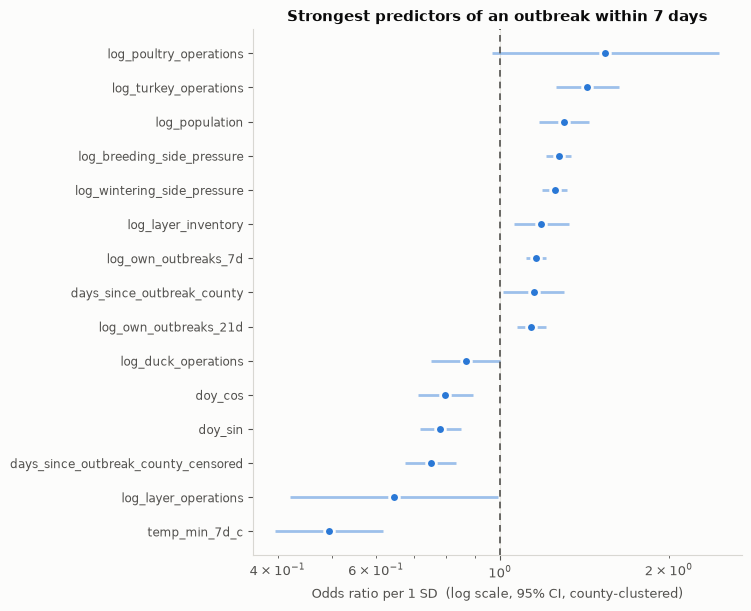

In [12]:
top = pd.concat([coef.head(9), coef.tail(6)]).sort_values("odds_ratio")
fig, ax = plt.subplots(figsize=(7.6, 6.2))
ypos = np.arange(len(top))

ax.hlines(ypos, top.ci_low, top.ci_high, color=BLUE, lw=2, alpha=0.45)
ax.plot(top.odds_ratio, ypos, "o", color=BLUE, markersize=7,
        markeredgecolor=SURFACE, markeredgewidth=2, linestyle="none")
ax.axvline(1.0, color=INK_2, lw=1.2, ls=(0, (4, 3)))

ax.set_yticks(ypos)
ax.set_yticklabels(top.index, fontsize=8.5)
ax.set_xscale("log")
ax.set(xlabel="Odds ratio per 1 SD  (log scale, 95% CI, county-clustered)",
       title="Strongest predictors of an outbreak within 7 days")
ax.grid(axis="y", visible=False)
fig.tight_layout()
plt.show()

## 6. What this is and is not

**Is:** an honest, leakage-checked, temporally-split baseline with population-valid test metrics —
the reference number that sentiment has to beat.

**Is not:** a tuned model. Deliberately absent, in rough order of expected payoff:

1. **No regularization path or nonlinear model.** A gradient-boosted tree will almost certainly
   beat this; logistic regression was chosen because its coefficients are interpretable and its
   failure modes are visible.
2. **No spatial random effect.** Clustered standard errors fix the *inference*, not the *fit* —
   counties still enter as independent rows.
3. **`own_outbreaks_*` probably dominates.** An already-infected county staying infected is real
   signal but a weak early-warning claim. Re-run with those columns dropped to see what the
   environmental and spatial features carry on their own.
4. **Banding features excluded** (`INCLUDE_BANDING = False`) because `fact_bird_density` ends
   2025-07-10, inside the test window.
5. **No permutation control yet.** The project's methodological control — shuffling a feature block
   and confirming performance degrades — is the natural next cell, and is what will make the
   eventual sentiment claim credible.
6. **Poultry exposure is a static 2022 snapshot** applied across 2022–2026, so it cannot reflect
   depopulation and restocking caused by the very outbreaks being modeled.